ĐỒ ÁN MẠNG XÃ HỘI



# Cài đặt

Chỉ chạy 2 cell này vào lần đầu tiên

In [ ]:
# Gỡ numpy cũ và cài đúng phiên bản tương thích (Chỉ chạy 1 lần)
!pip uninstall -y numpy
!pip install numpy==1.25.0

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 75.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.25.0 which is incompatible.
blosc2 3.3.2 requires numpy>=1.26, but you have numpy 1.25.0 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.25.0 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.25.0 which is incompatible.


In [ ]:
!pip install networkx #chỉ chạy 1 lần

Mỗi lần connect lại thì chạy cell này và các cell sau

In [1]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
  -f https://data.pyg.org/whl/torch-2.1.0+cu118.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 18.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 31.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 17.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.8/891.8 kB 16.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.0 MB/s eta 0:00:00


# Import

In [2]:
# Kết nối Google Colab với Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [4]:
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling

/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_spline_conv/_version_cuda.so: undefined symbol: _ZN3c1017Registe

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

In [6]:
import networkx as nx

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [8]:
import random

In [9]:
from sklearn.metrics import roc_auc_score
from torch_geometric.utils import negative_sampling

In [10]:
from collections import defaultdict

In [11]:
from torch_geometric.utils import train_test_split_edges

In [12]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
# Để các lần chạy không chênh lệch lớn
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Lưu ý phải thêm file_path đúng

In [15]:
# Đọc file .csv
file_path = '/content/drive/MyDrive/BIOGRID-CORONAVIRUS.csv'
# Đọc file vào DataFrame
df = pd.read_csv(file_path)

In [16]:
df.head()

,#BioGRID Interaction ID,Entrez Gene Interactor A,Entrez Gene Interactor B,BioGRID ID Interactor A,BioGRID ID Interactor B,Systematic Name Interactor A,Systematic Name Interactor B,Official Symbol Interactor A,Official Symbol Interactor B,Synonyms Interactor A,...,TREMBL Accessions Interactor B,REFSEQ Accessions Interactor B,Ontology Term IDs,Ontology Term Names,Ontology Term Categories,Ontology Term Qualifier IDs,Ontology Term Qualifier Names,Ontology Term Types,Organism Name Interactor A,Organism Name Interactor B
0,141211,850980,852501,31542,32899,YLR274W,YBR202W,MCM5,MCM7,BOB1|CDC46|MCM DNA helicase complex subunit MC...,...,-,NP_009761,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)
1,141212,852501,850980,32899,31542,YBR202W,YLR274W,MCM7,MCM5,CDC47|MCM DNA helicase complex subunit MCM7|L0...,...,-,NP_013376,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)
2,141213,850980,856680,31542,36697,YLR274W,YEL032W,MCM5,MCM3,BOB1|CDC46|MCM DNA helicase complex subunit MC...,...,-,NP_010882,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)
3,141214,856680,850980,36697,31542,YEL032W,YLR274W,MCM3,MCM5,MCM DNA helicase complex subunit MCM3|L000001039,...,-,NP_013376,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)
4,141215,852501,850793,32899,31376,YBR202W,YLR103C,MCM7,CDC45,CDC47|MCM DNA helicase complex subunit MCM7|L0...,...,-,NP_013204,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)


In [17]:
print(df.dtypes)

#BioGRID Interaction ID                int64
Entrez Gene Interactor A              object
Entrez Gene Interactor B              object
BioGRID ID Interactor A                int64
BioGRID ID Interactor B                int64
Systematic Name Interactor A          object
Systematic Name Interactor B          object
Official Symbol Interactor A          object
Official Symbol Interactor B          object
Synonyms Interactor A                 object
Synonyms Interactor B                 object
Experimental System                   object
Experimental System Type              object
Author                                object
Publication Source                    object
Organism ID Interactor A               int64
Organism ID Interactor B               int64
Throughput                            object
Score                                 object
Modification                          object
Qualifications                        object
Tags                                  object
Source Dat

In [18]:
print(df.isnull().sum())

#BioGRID Interaction ID                0
Entrez Gene Interactor A               0
Entrez Gene Interactor B               0
BioGRID ID Interactor A                0
BioGRID ID Interactor B                0
Systematic Name Interactor A           0
Systematic Name Interactor B           0
Official Symbol Interactor A           0
Official Symbol Interactor B           0
Synonyms Interactor A                  0
Synonyms Interactor B                  0
Experimental System                    0
Experimental System Type               0
Author                                 0
Publication Source                     0
Organism ID Interactor A               0
Organism ID Interactor B               0
Throughput                             0
Score                                  0
Modification                           0
Qualifications                         0
Tags                                   0
Source Database                        0
SWISS-PROT Accessions Interactor A     0
TREMBL Accession

# Tiền xử lý dữ liệu

In [19]:
columns_to_keep = [
    "BioGRID ID Interactor A",
    "Official Symbol Interactor A",
    "BioGRID ID Interactor B",
    "Official Symbol Interactor B",
    "Experimental System Type",
    "Experimental System"
]

df = df[columns_to_keep]

In [20]:
# Thay thế tất cả giá trị "-" bằng NaN
df = df.replace("-", np.nan)

# Xoá các hàng có bất kỳ giá trị NaN nào
df = df.dropna()

In [21]:
df.isnull().sum()

,0
BioGRID ID Interactor A,0
Official Symbol Interactor A,0
BioGRID ID Interactor B,0
Official Symbol Interactor B,0
Experimental System Type,0
Experimental System,0


In [22]:
print(df.head())

   BioGRID ID Interactor A Official Symbol Interactor A  \
0                    31542                         MCM5   
1                    32899                         MCM7   
2                    31542                         MCM5   
3                    36697                         MCM3   
4                    32899                         MCM7   

   BioGRID ID Interactor B Official Symbol Interactor B  \
0                    32899                         MCM7   
1                    31542                         MCM5   
2                    36697                         MCM3   
3                    31542                         MCM5   
4                    31376                        CDC45   

  Experimental System Type Experimental System  
0                 physical          Two-hybrid  
1                 physical          Two-hybrid  
2                 physical          Two-hybrid  
3                 physical          Two-hybrid  
4                 physical          Two-hybri

# Trực quan dữ liệu

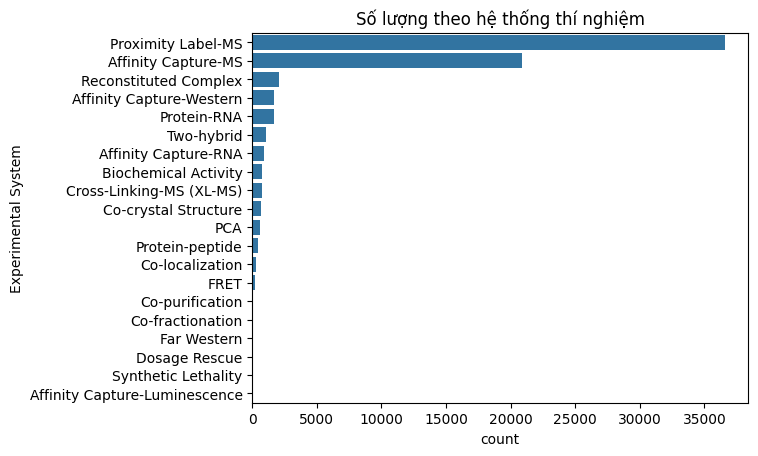

In [23]:
sns.countplot(y='Experimental System', data=df, order=df['Experimental System'].value_counts().index)
plt.title('Số lượng theo hệ thống thí nghiệm')
plt.show()

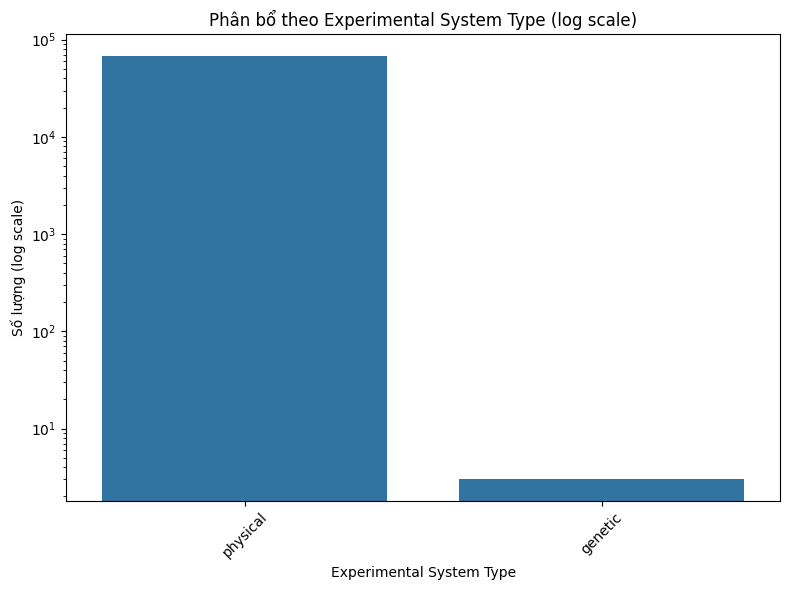

In [24]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Experimental System Type')
plt.yscale('log')
plt.title('Phân bổ theo Experimental System Type (log scale)')
plt.xlabel('Experimental System Type')
plt.ylabel('Số lượng (log scale)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-25-7624675a4ba2>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


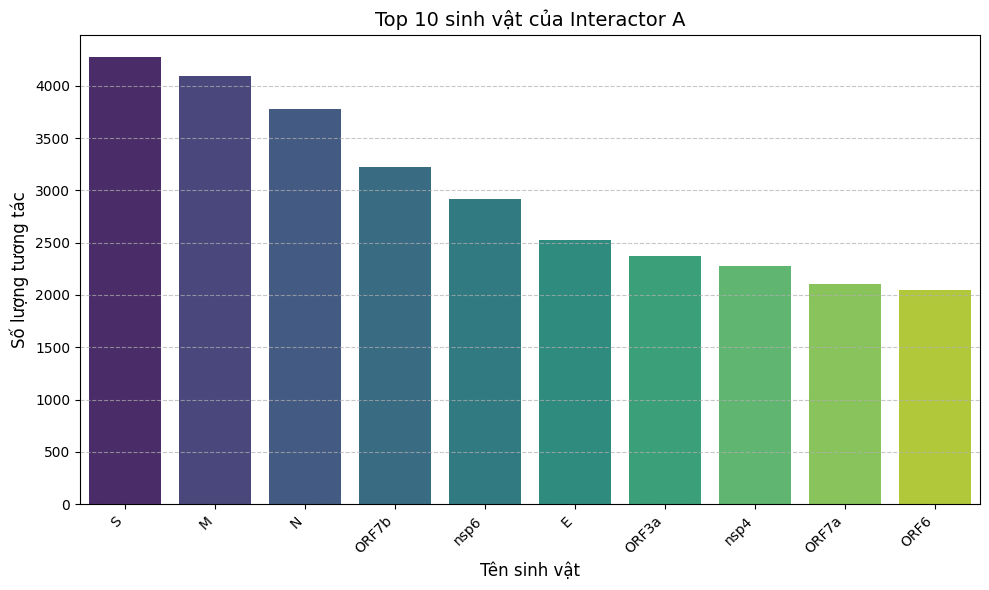

In [25]:
# Tính toán top 10 sinh vật phổ biến nhất
top_speciesA = df['Official Symbol Interactor A'].value_counts().nlargest(10)

# Vẽ biểu đồ với màu sắc và kích thước rõ hơn
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_speciesA.index,
    y=top_speciesA.values,
    palette="viridis"
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Top 10 sinh vật của Interactor A', fontsize=14)
plt.xlabel('Tên sinh vật', fontsize=12)
plt.ylabel('Số lượng tương tác', fontsize=12)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<ipython-input-26-ed7710f9fc6e>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


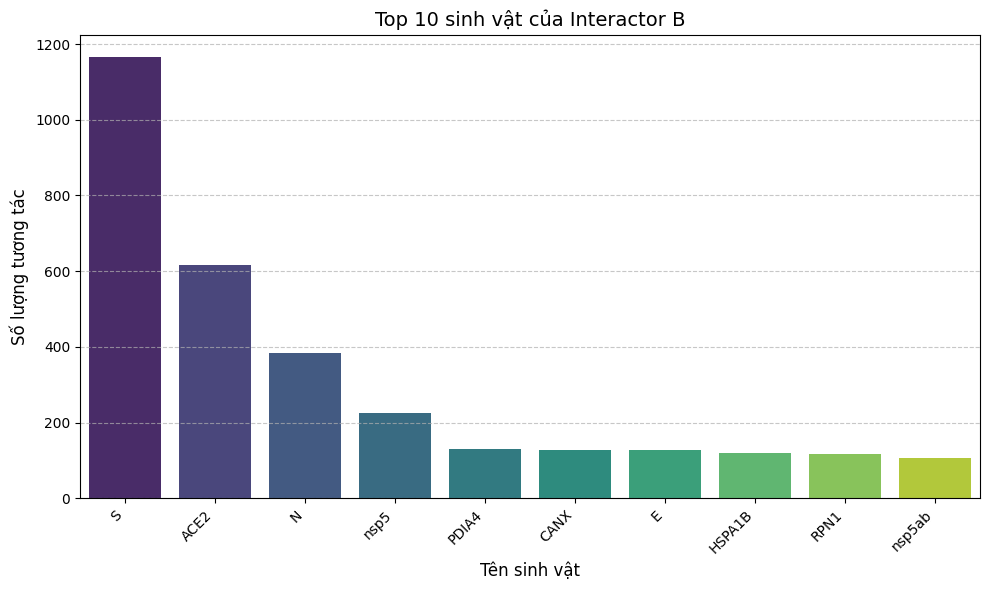

In [26]:
# Tính toán top 10 sinh vật phổ biến nhất
top_speciesB = df['Official Symbol Interactor B'].value_counts().nlargest(10)

# Vẽ biểu đồ với màu sắc và kích thước rõ hơn
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_speciesB.index,
    y=top_speciesB.values,
    palette="viridis"
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Top 10 sinh vật của Interactor B', fontsize=14)
plt.xlabel('Tên sinh vật', fontsize=12)
plt.ylabel('Số lượng tương tác', fontsize=12)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Xây dựng đồ thị

In [27]:
# Chuẩn bị node & edge
nodes_A = df[["BioGRID ID Interactor A", "Official Symbol Interactor A"]].rename(
    columns={"BioGRID ID Interactor A": "ID", "Official Symbol Interactor A": "Protein"}
)
nodes_B = df[["BioGRID ID Interactor B", "Official Symbol Interactor B"]].rename(
    columns={"BioGRID ID Interactor B": "ID", "Official Symbol Interactor B": "Protein"}
)
nodes = pd.concat([nodes_A, nodes_B]).drop_duplicates().reset_index(drop=True)
edges = df[["BioGRID ID Interactor A", "BioGRID ID Interactor B"]].drop_duplicates()
# Xây dựng đồ thị NetworkX
G = nx.Graph()
G.add_edges_from(edges.values)
node_info = dict(zip(nodes["ID"], nodes["Protein"]))
nx.set_node_attributes(G, node_info, name="Protein")

In [28]:
# Loại bỏ các cột trùng lặp (chỉ giữ lại một bộ ID - Protein)
nodes = nodes.loc[:, ~nodes.columns.duplicated()]
print(nodes.head())  # Kiểm tra lại dữ liệu sau khi xử lý

       ID Protein
0   31542    MCM5
1   32899    MCM7
2   36697    MCM3
3   34611    RUD3
4  107067   CCND1


In [29]:
nodes["ID"] = nodes["ID"].astype(int)

In [30]:
# Số lượng nodes (đỉnh)
num_nodes = G.number_of_nodes()
print(f"Số lượng nodes: {num_nodes}")

# Số lượng edges (cạnh)
num_edges = G.number_of_edges()
print(f"Số lượng edges: {num_edges}")

Số lượng nodes: 8571
Số lượng edges: 49029


# Trực quan hoá đồ thị


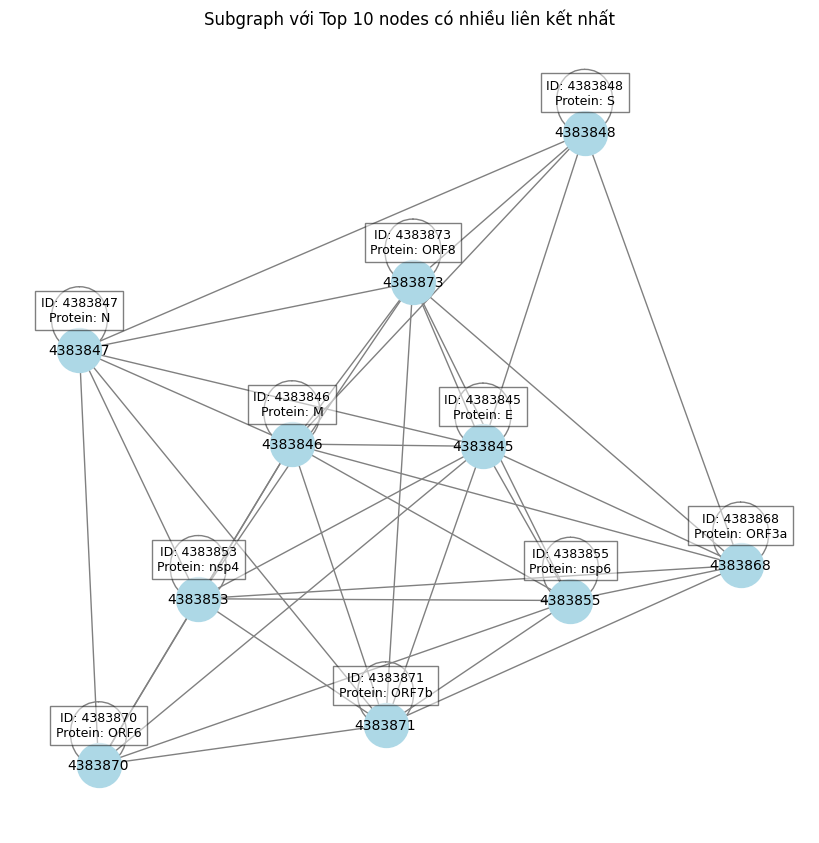

In [31]:
# Chọn 10 node có nhiều liên kết nhất
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:10]
subgraph_nodes = [node for node, _ in top_nodes]
subgraph = G.subgraph(subgraph_nodes)  # Tạo subgraph

# Vẽ đồ thị với layout tối ưu liên kết
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(subgraph, seed=42)  # Giữ node có nhiều liên kết gần nhau
nx.draw(subgraph, pos, with_labels=True, node_size=1000, node_color="lightblue", font_size=10, edge_color="gray")

# Đẩy thuộc tính ra xa khỏi node
offset = 0.08  # Điều chỉnh khoảng cách giữa node và text
for node, (x, y) in pos.items():
    protein_name = node_info.get(node, "Unknown")  # Lấy Protein Name từ dictionary
    text = f"ID: {node}\nProtein: {protein_name}"  # Hiển thị cả ID và Protein Name
    plt.text(x, y + offset, text, fontsize=9, ha='center', bbox=dict(facecolor="white", alpha=0.5))

plt.title("Subgraph với Top 10 nodes có nhiều liên kết nhất")
plt.show()

#Trích xuất các đặc trưng

**1. Các đặc trưng đồ thị (Graph Features):**
- clustering: Hệ số gom cụm
- pagerank: Tầm quan trọng theo PageRank
- betweenness: Độ trung gian
- eigenvector: Ảnh hưởng trong đồ thị
- triangle_count: Số tam giác node tham gia
- closeness centrality
- degreee centrality

**2. Đặc trưng sinh học từ DataFrame:**
- physical_ratio: Tỷ lệ tương tác vật lý
- genetic_ratio: Tỷ lệ tương tác di truyền


In [32]:
degree_centrality = nx.degree_centrality(G)
closeness = nx.closeness_centrality(G)
betweenness = nx.betweenness_centrality(G)
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
clustering = nx.clustering(G)
pagerank = nx.pagerank(G)
triangle_count = nx.triangles(G)

In [33]:
# Tạo đặc trưng từ BioGRID
def extract_biogrid_features(df):
    physical_counts = defaultdict(int)
    genetic_counts = defaultdict(int)

    for _, row in df.iterrows():
        type_ = row['Experimental System Type']
        method = row['Experimental System']
        a = row['BioGRID ID Interactor A']
        b = row['BioGRID ID Interactor B']

        if type_ == 'physical':
            physical_counts[a] += 1
            physical_counts[b] += 1
        elif type_ == 'genetic':
            genetic_counts[a] += 1
            genetic_counts[b] += 1

    all_nodes = set(physical_counts) | set(genetic_counts)
    features = {}
    for node in all_nodes:
        phys = physical_counts[node]
        gen = genetic_counts[node]
        total = phys + gen if (phys + gen) > 0 else 1
        features[node] = {
            'physical_ratio': phys / total,
            'genetic_ratio': gen / total
        }

    return features

biogrid_features = extract_biogrid_features(df)

In [34]:
feature_df_raw = pd.DataFrame({
    "betweenness": list(betweenness.values()),
    "eigenvector": list(eigenvector.values()),
    "clustering": list(clustering.values()),
    "pagerank": list(pagerank.values()),
    "triangle_count": list(triangle_count.values()),
    "closeness": list(closeness.values()),
    "degree_centrality": list(degree_centrality.values()),
    "physical_ratio": [v['physical_ratio'] for v in biogrid_features.values()],
    "genetic_ratio": [v['genetic_ratio'] for v in biogrid_features.values()]
})

# In thống kê mô tả gốc
print(feature_df_raw.describe())

       betweenness    eigenvector   clustering     pagerank  triangle_count  \
count  8571.000000   8.571000e+03  8571.000000  8571.000000     8571.000000   
mean      0.000215   5.437037e-03     0.284881     0.000117       32.564578   
std       0.003387   9.333879e-03     0.325283     0.000712      377.910352   
min       0.000000  5.043384e-107     0.000000     0.000024        0.000000   
25%       0.000000   1.112075e-03     0.000000     0.000028        0.000000   
50%       0.000002   2.599317e-03     0.190476     0.000045        1.000000   
75%       0.000021   7.056630e-03     0.483333     0.000082       10.000000   
max       0.157291   2.475353e-01     1.000000     0.025322    15823.000000   

         closeness  degree_centrality  physical_ratio  genetic_ratio  
count  8571.000000        8571.000000     8571.000000    8571.000000  
mean      0.351743           0.001335        0.999800       0.000200  
std       0.051961           0.008610        0.011569       0.011569  
min 

# Phân phối các đặc trưng đã tính

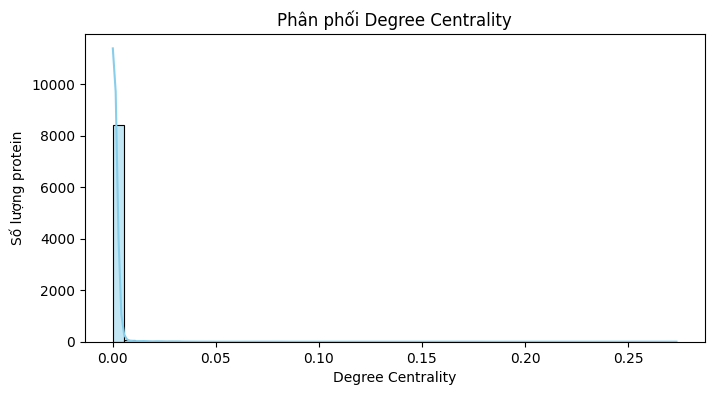

In [35]:
plt.figure(figsize=(8,4))
sns.histplot(list(degree_centrality.values()), bins=50, kde=True, color='skyblue')
plt.title("Phân phối Degree Centrality")
plt.xlabel("Degree Centrality")
plt.ylabel("Số lượng protein")
plt.show()

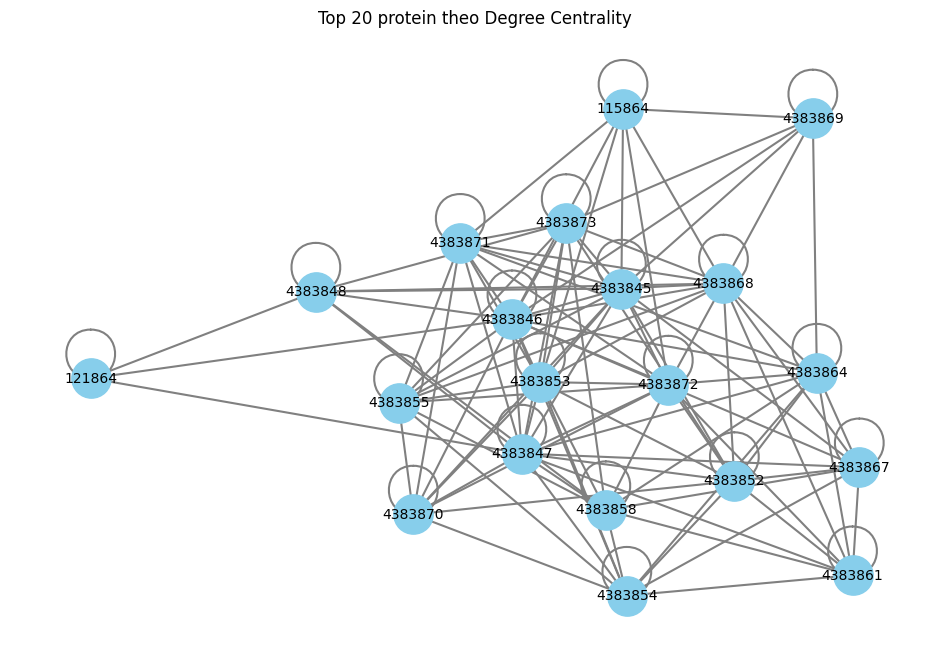

In [36]:
# Sắp xếp theo degree centrality
top_deg_nodes = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:20]

# Tạo đồ thị con từ 20 protein đó
G_top_deg = G.subgraph(top_deg_nodes)

# Vẽ đồ thị
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_top_deg, seed=42)  # sơ đồ dạng lò xo
nx.draw_networkx_nodes(G_top_deg, pos, node_size=800, node_color='skyblue')
nx.draw_networkx_edges(G_top_deg, pos, width=1.5, edge_color='gray')
nx.draw_networkx_labels(G_top_deg, pos, font_size=10)
plt.title("Top 20 protein theo Degree Centrality")
plt.axis('off')
plt.show()

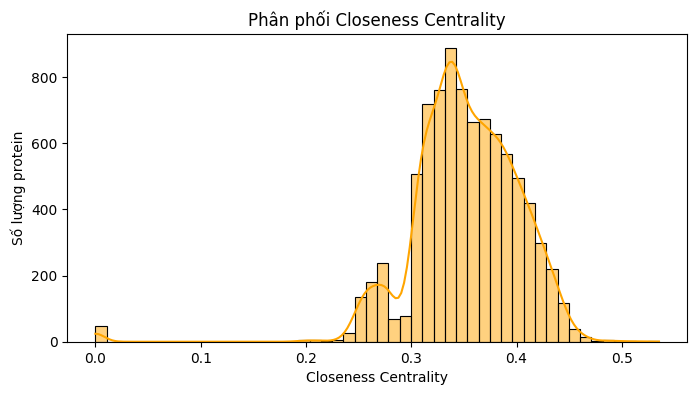

In [37]:
plt.figure(figsize=(8,4))
sns.histplot(list(closeness.values()), bins=50, kde=True, color='orange')
plt.title("Phân phối Closeness Centrality")
plt.xlabel("Closeness Centrality")
plt.ylabel("Số lượng protein")
plt.show()

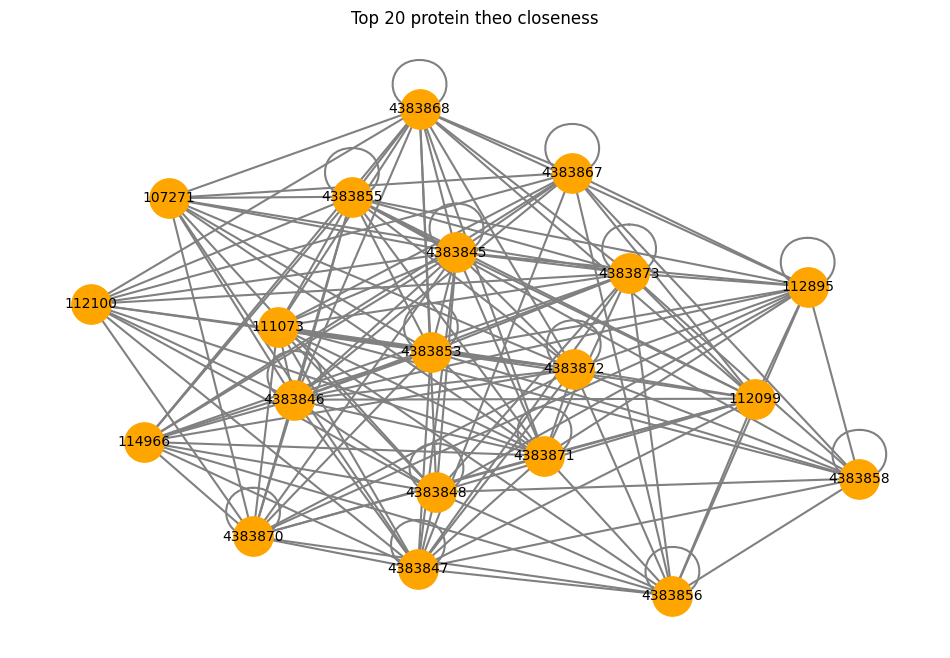

In [38]:
top_bet_nodes = sorted(closeness, key=closeness.get, reverse=True)[:20]
G_top_bet = G.subgraph(top_bet_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_top_bet, seed=42)
nx.draw_networkx_nodes(G_top_bet, pos, node_size=800, node_color='orange')
nx.draw_networkx_edges(G_top_bet, pos, width=1.5, edge_color='gray')
nx.draw_networkx_labels(G_top_bet, pos, font_size=10)
plt.title("Top 20 protein theo closeness")
plt.axis('off')
plt.show()

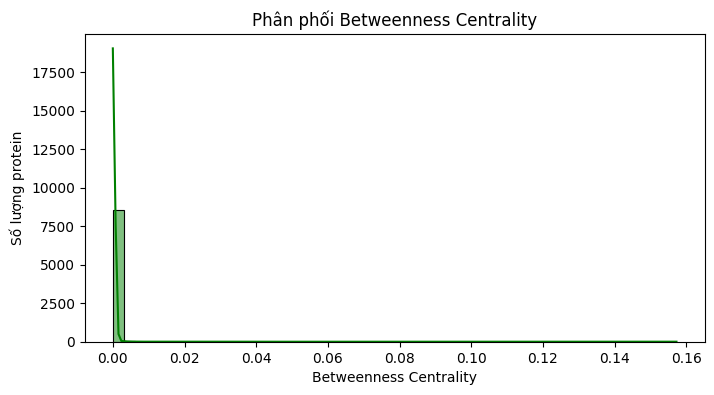

In [39]:
plt.figure(figsize=(8,4))
sns.histplot(list(betweenness.values()), bins=50, kde=True, color='green')
plt.title("Phân phối Betweenness Centrality")
plt.xlabel("Betweenness Centrality")
plt.ylabel("Số lượng protein")
plt.show()

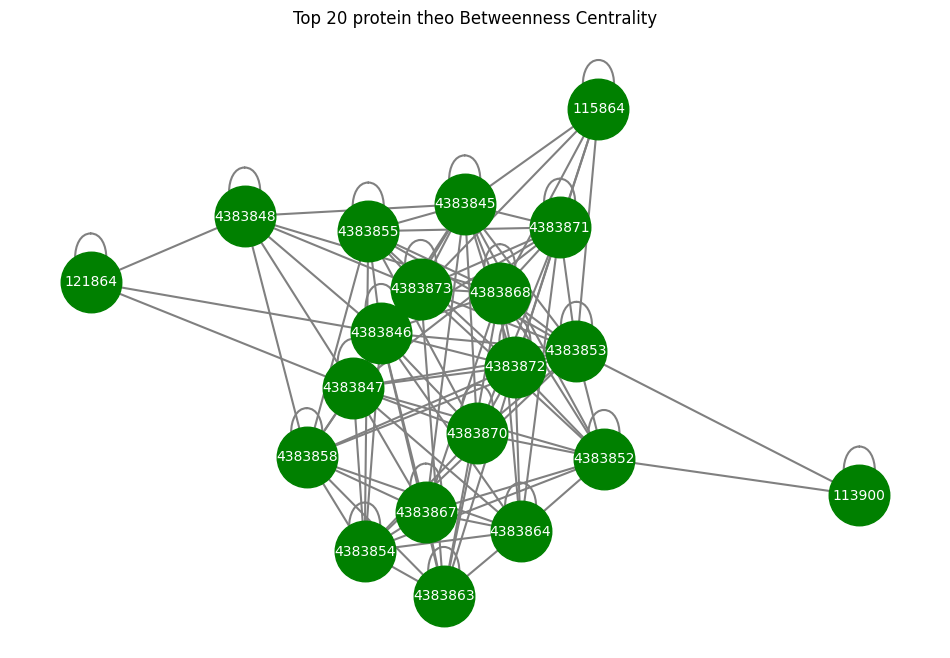

In [85]:
top_bet_nodes = sorted(betweenness, key=betweenness.get, reverse=True)[:20]
G_top_bet = G.subgraph(top_bet_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_top_bet, seed=42)
nx.draw_networkx_nodes(G_top_bet, pos, node_size=1900, node_color='green')
nx.draw_networkx_edges(G_top_bet, pos, width=1.5, edge_color='gray')
nx.draw_networkx_labels(G_top_bet, pos, font_size=10, font_color='white')
plt.title("Top 20 protein theo Betweenness Centrality")
plt.axis('off')
plt.show()

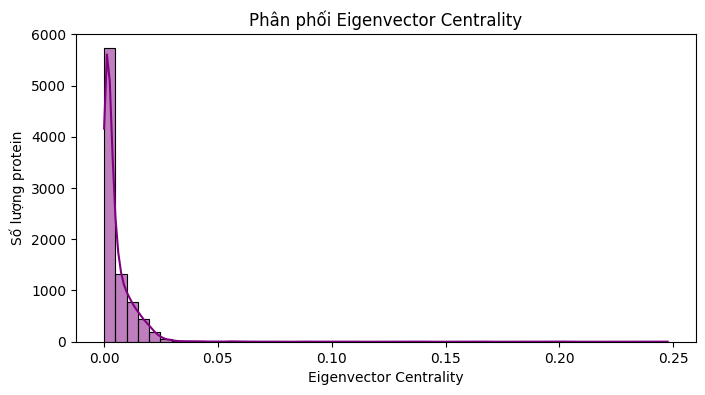

In [41]:
plt.figure(figsize=(8,4))
sns.histplot(list(eigenvector.values()), bins=50, kde=True, color='purple')
plt.title("Phân phối Eigenvector Centrality")
plt.xlabel("Eigenvector Centrality")
plt.ylabel("Số lượng protein")
plt.show()

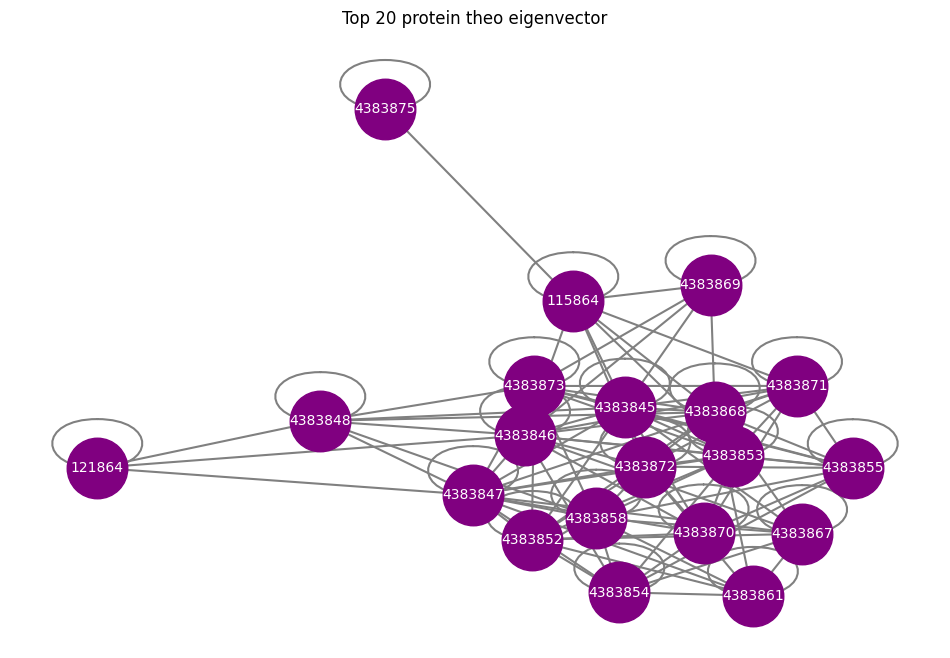

In [87]:
top_bet_nodes = sorted(eigenvector, key=eigenvector.get, reverse=True)[:20]
G_top_bet = G.subgraph(top_bet_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_top_bet, seed=42)
nx.draw_networkx_nodes(G_top_bet, pos, node_size=1900, node_color='purple')
nx.draw_networkx_edges(G_top_bet, pos, width=1.5, edge_color='gray')
nx.draw_networkx_labels(G_top_bet, pos, font_size=10, font_color='white')
plt.title("Top 20 protein theo eigenvector")
plt.axis('off')
plt.show()

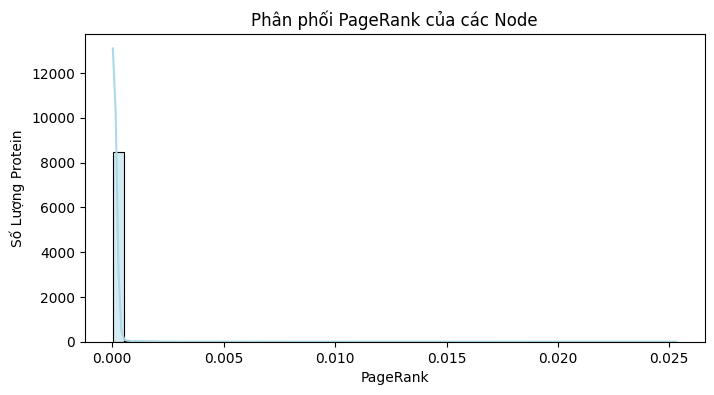

In [43]:
# Lấy các giá trị của PageRank
pagerank_values = list(pagerank.values())

# Vẽ biểu đồ phân phối PageRank
plt.figure(figsize=(8, 4))
sns.histplot(pagerank_values, bins=50, kde=True, color='lightblue')
plt.title("Phân phối PageRank của các Node")
plt.xlabel("PageRank")
plt.ylabel("Số Lượng Protein")
plt.show()

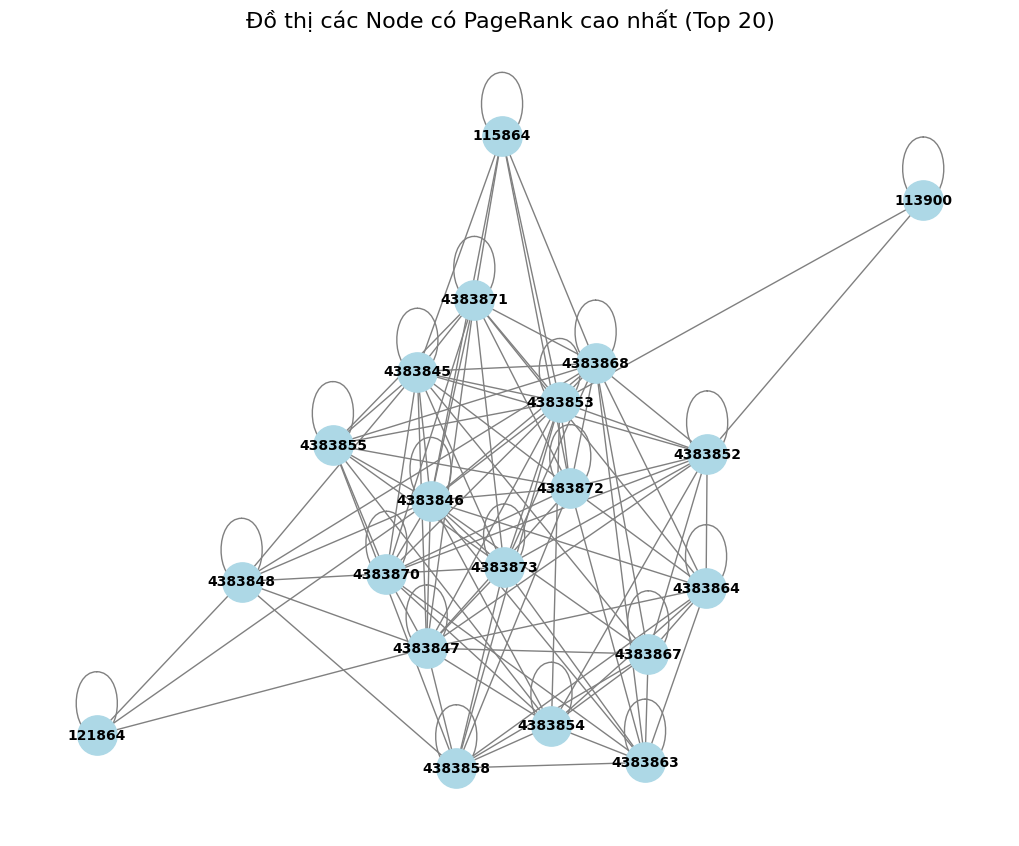

In [44]:
# Lấy top 20 node có PageRank cao nhất
top_pagerank_nodes = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:20]
top_pagerank_node_ids = [node for node, score in top_pagerank_nodes]

# Tạo subgraph chỉ chứa các node có PageRank cao nhất
subgraph_pagerank = G.subgraph(top_pagerank_node_ids)

# Vẽ đồ thị các node có PageRank cao nhất
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(subgraph_pagerank)
nx.draw(subgraph_pagerank, pos, with_labels=True, node_size=800, node_color='lightblue', font_size=10, font_weight='bold', edge_color='gray')
plt.title("Đồ thị các Node có PageRank cao nhất (Top 20)", fontsize=16)
plt.show()

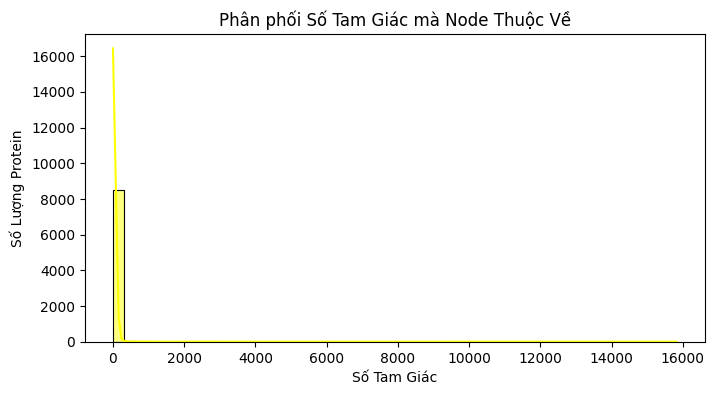

In [45]:
plt.figure(figsize=(8, 4))
sns.histplot(list(triangle_count.values()), bins=50, kde=True, color='yellow')
plt.title("Phân phối Số Tam Giác mà Node Thuộc Về")
plt.xlabel("Số Tam Giác")
plt.ylabel("Số Lượng Protein")
plt.show()

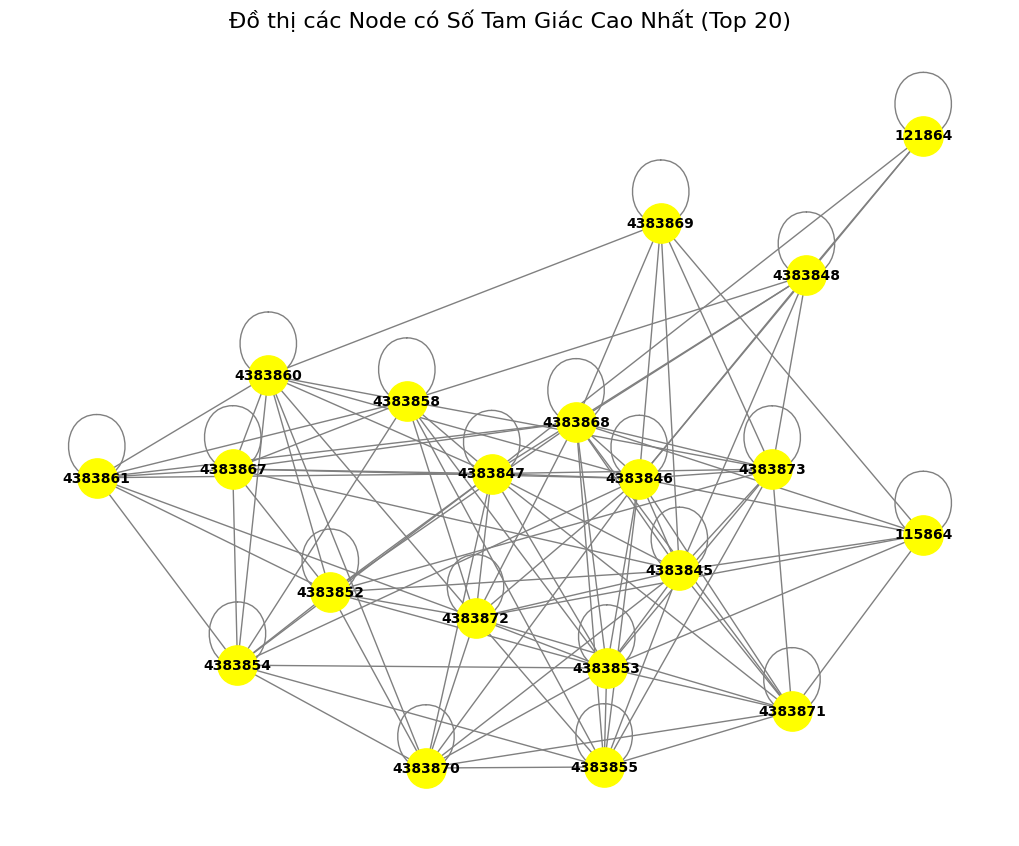

In [46]:
# Lấy top 20 node có số tam giác cao nhất
top_triangle_nodes = sorted(triangle_count.items(), key=lambda x: x[1], reverse=True)[:20]
top_triangle_node_ids = [node for node, count in top_triangle_nodes]

# Tạo subgraph chỉ chứa các node có số tam giác cao nhất
subgraph_triangle = G.subgraph(top_triangle_node_ids)

# Vẽ đồ thị các node có số tam giác cao nhất
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(subgraph_triangle)  # Tạo layout cho đồ thị
nx.draw(subgraph_triangle, pos, with_labels=True, node_size=800, node_color='yellow', font_size=10, font_weight='bold', edge_color='gray')
plt.title("Đồ thị các Node có Số Tam Giác Cao Nhất (Top 20)", fontsize=16)
plt.show()

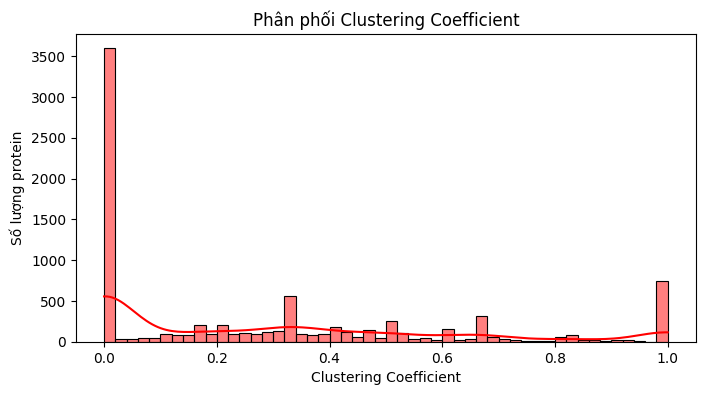

In [47]:
plt.figure(figsize=(8,4))
sns.histplot(list(clustering.values()), bins=50, kde=True, color='red')
plt.title("Phân phối Clustering Coefficient")
plt.xlabel("Clustering Coefficient")
plt.ylabel("Số lượng protein")
plt.show()

Text(0, 0.5, 'Số lượng Protein')

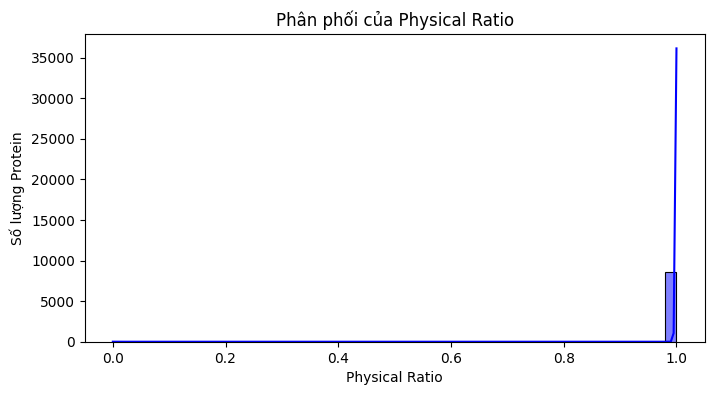

In [48]:
physical_ratios = [features['physical_ratio'] for features in biogrid_features.values()]

plt.figure(figsize=(8, 4))
sns.histplot(physical_ratios, kde=True, color='blue', bins=50)
plt.title('Phân phối của Physical Ratio')
plt.xlabel('Physical Ratio')
plt.ylabel('Số lượng Protein')

Text(0, 0.5, 'Số lượng Protein')

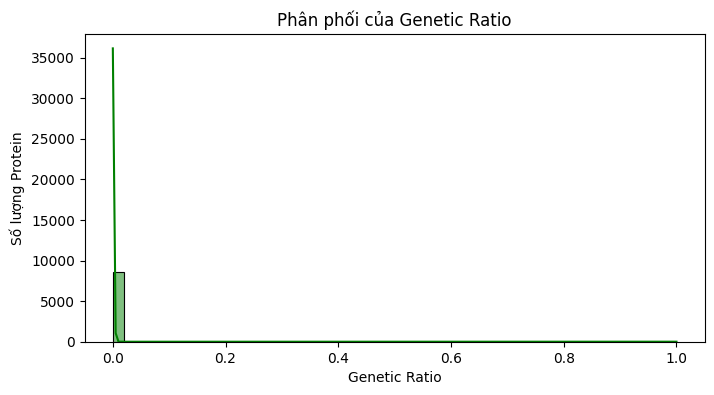

In [49]:
genetic_ratios = [features['genetic_ratio'] for features in biogrid_features.values()]

plt.figure(figsize=(8, 4))
sns.histplot(genetic_ratios, kde=True, color='green', bins=50)
plt.title('Phân phối của Genetic Ratio')
plt.xlabel('Genetic Ratio')
plt.ylabel('Số lượng Protein')

Tổng hợp phân phối

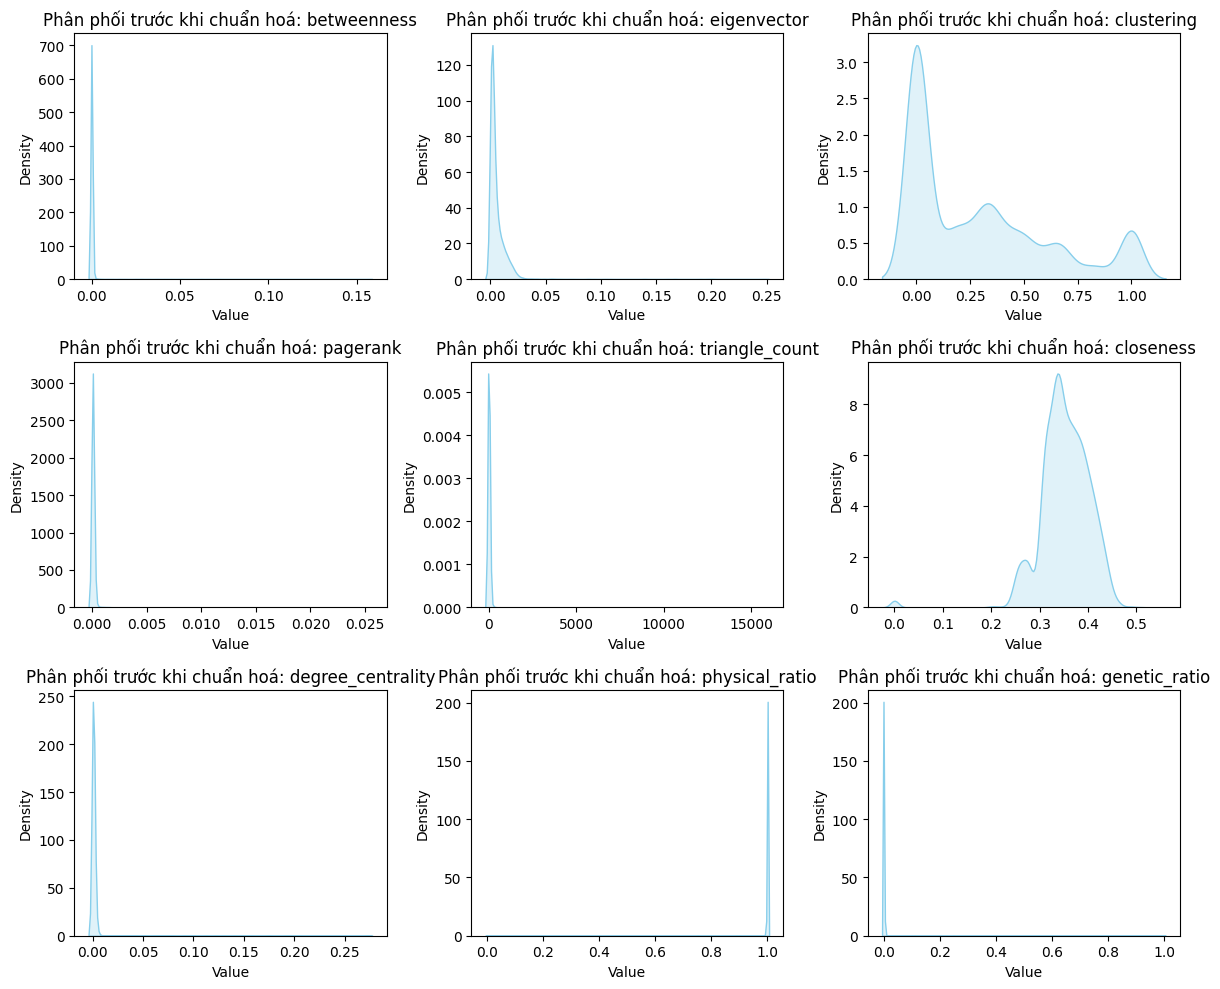

In [50]:
plt.figure(figsize=(12, 10))

# Lặp qua các cột của DataFrame và vẽ biểu đồ phân phối cho từng đặc trưng
for i, feature in enumerate(feature_df_raw.columns):
    plt.subplot(3, 3, i + 1)  # Sắp xếp các biểu đồ theo 3x3
    sns.kdeplot(feature_df_raw[feature], fill=True, color='skyblue')  # Vẽ phân phối KDE
    plt.title(f'Phân phối trước khi chuẩn hoá: {feature}')
    plt.xlabel('Value')
    plt.ylabel('Density')

plt.tight_layout()  # Đảm bảo không bị chồng chéo
plt.show()

In [51]:
def log_transform(data):
    data = np.asarray(data).flatten()  # Đảm bảo 1 chiều
    data = np.where(np.isnan(data), 0, data)  # Thay NaN bằng 0
    data = np.where(data < 0, 0, data)        # Thay giá trị âm bằng 0
    return np.log1p(data)

In [52]:
# Áp dụng log transform cho các đặc trưng
log_betweenness = log_transform(np.array(list(betweenness.values())))
log_eigenvector = log_transform(np.array(list(eigenvector.values())))
log_clustering = log_transform(np.array(list(clustering.values())))
log_pagerank = log_transform(np.array(list(pagerank.values())))
log_triangle_count = log_transform(np.array(list(triangle_count.values())))
log_closeness = log_transform(np.array(list(closeness.values())))
log_degree_centrality = log_transform(np.array(list(degree_centrality.values())))

physical_vals = [v['physical_ratio'] for v in biogrid_features.values()]
genetic_vals = [v['genetic_ratio'] for v in biogrid_features.values()]

In [53]:
# Log transform các đặc trưng
log_features_df = pd.DataFrame({
    "log_betweenness": log_transform(np.array(list(betweenness.values()))),
    "log_eigenvector": log_transform(np.array(list(eigenvector.values()))),
    "log_clustering": log_transform(np.array(list(clustering.values()))),
    "log_pagerank": log_transform(np.array(list(pagerank.values()))),
    "log_triangle_count": log_transform(np.array(list(triangle_count.values()))),
    "log_closeness": log_transform(np.array(list(closeness.values()))),
    "log_degree_centrality": log_transform(np.array(list(degree_centrality.values()))),
    "log_physical_ratio": log_transform(np.array(physical_vals)),
    "log_genetic_ratio": log_transform(np.array(genetic_vals))
})

# In thống kê mô tả
print(log_features_df.describe())

       log_betweenness  log_eigenvector  log_clustering  log_pagerank  \
count      8571.000000     8.571000e+03     8571.000000   8571.000000   
mean          0.000209     5.381835e-03        0.221561      0.000116   
std           0.003237     8.862777e-03        0.235783      0.000706   
min           0.000000    5.043384e-107        0.000000      0.000024   
25%           0.000000     1.111457e-03        0.000000      0.000028   
50%           0.000002     2.595945e-03        0.174353      0.000045   
75%           0.000021     7.031848e-03        0.394292      0.000082   
max           0.146082     2.211698e-01        0.693147      0.025007   

       log_triangle_count  log_closeness  log_degree_centrality  \
count         8571.000000    8571.000000            8571.000000   
mean             1.357072       0.300615               0.001301   
std              1.543274       0.040101               0.007957   
min              0.000000       0.000000               0.000117   
25%    

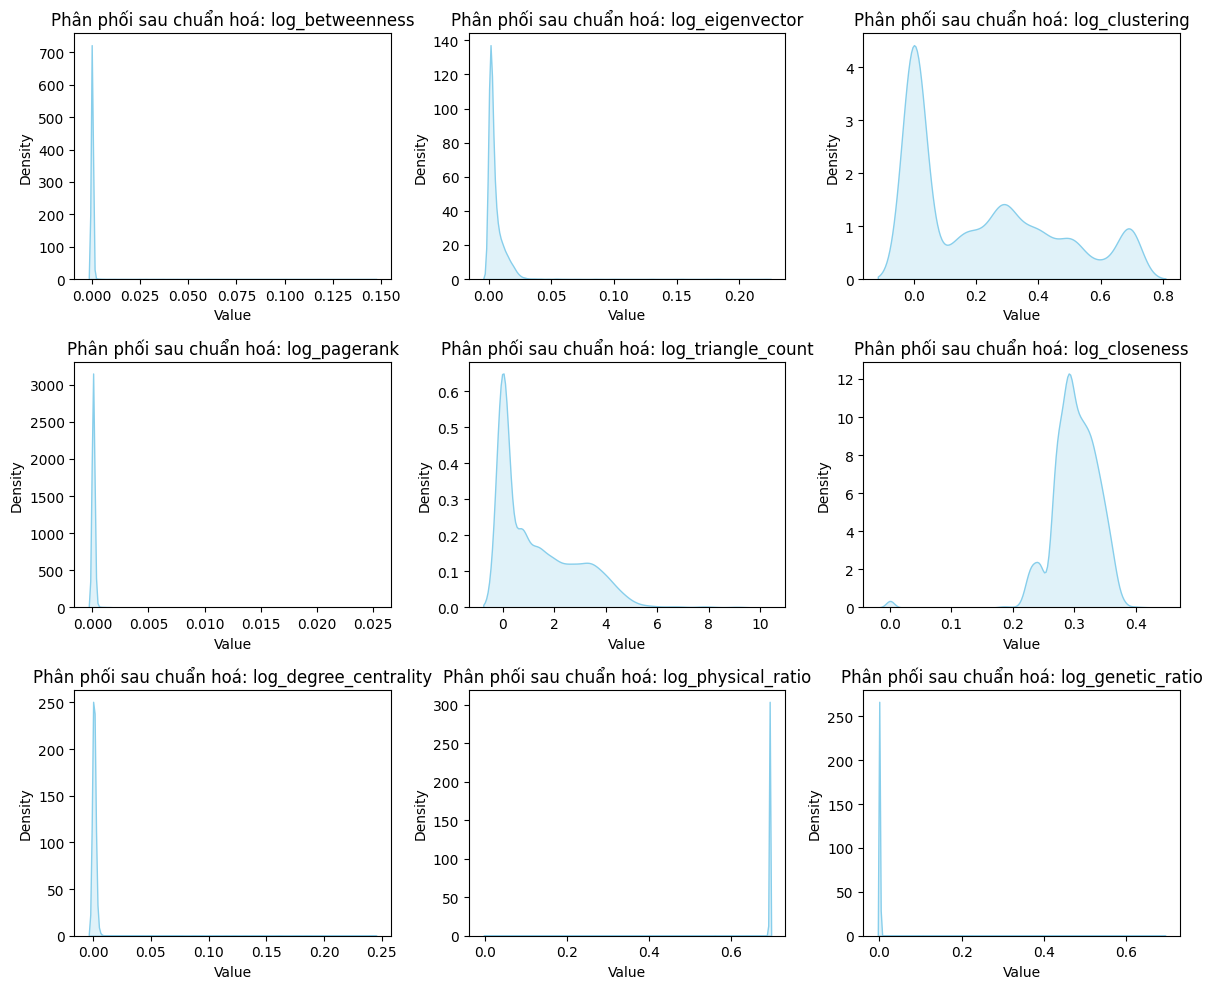

In [54]:
plt.figure(figsize=(12, 10))

for i, feature in enumerate(log_features_df.columns):
    plt.subplot(3, 3, i + 1)  # Bố cục 3x3
    sns.kdeplot(log_features_df[feature], fill=True, color='skyblue')
    plt.title(f'Phân phối sau chuẩn hoá: {feature}')
    plt.xlabel('Value')
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

# Lựa chọn đặc trưng

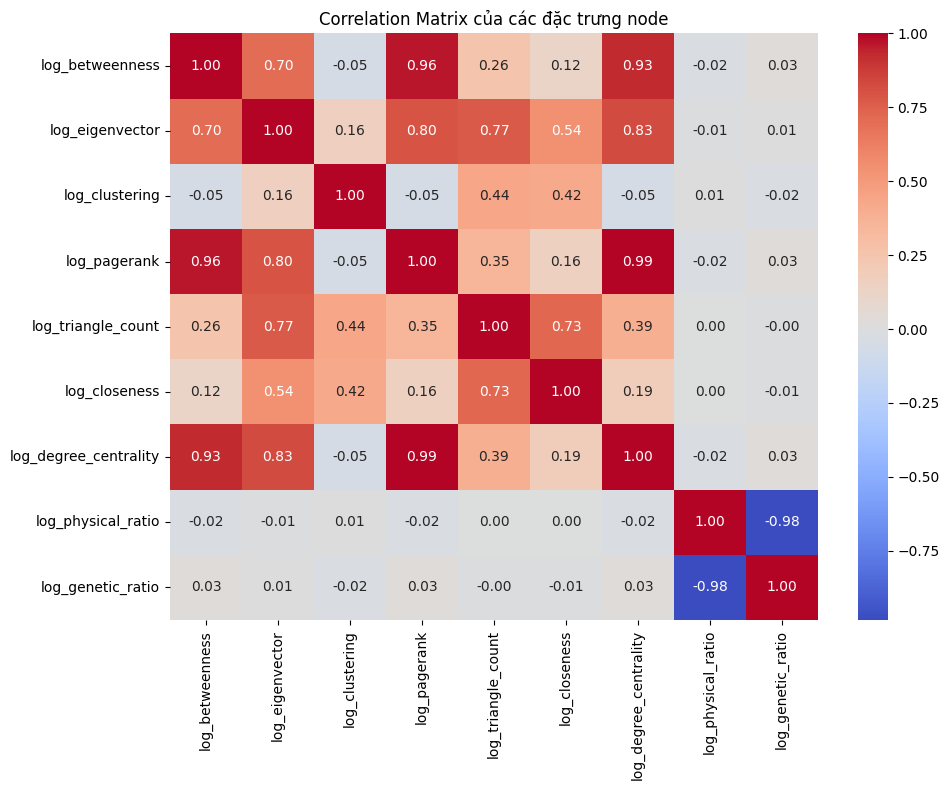

In [55]:
# Tính ma trận tương quan
corr_matrix = log_features_df.corr()

# Hiển thị ma trận tương quan
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix của các đặc trưng node")
plt.tight_layout()
plt.show()

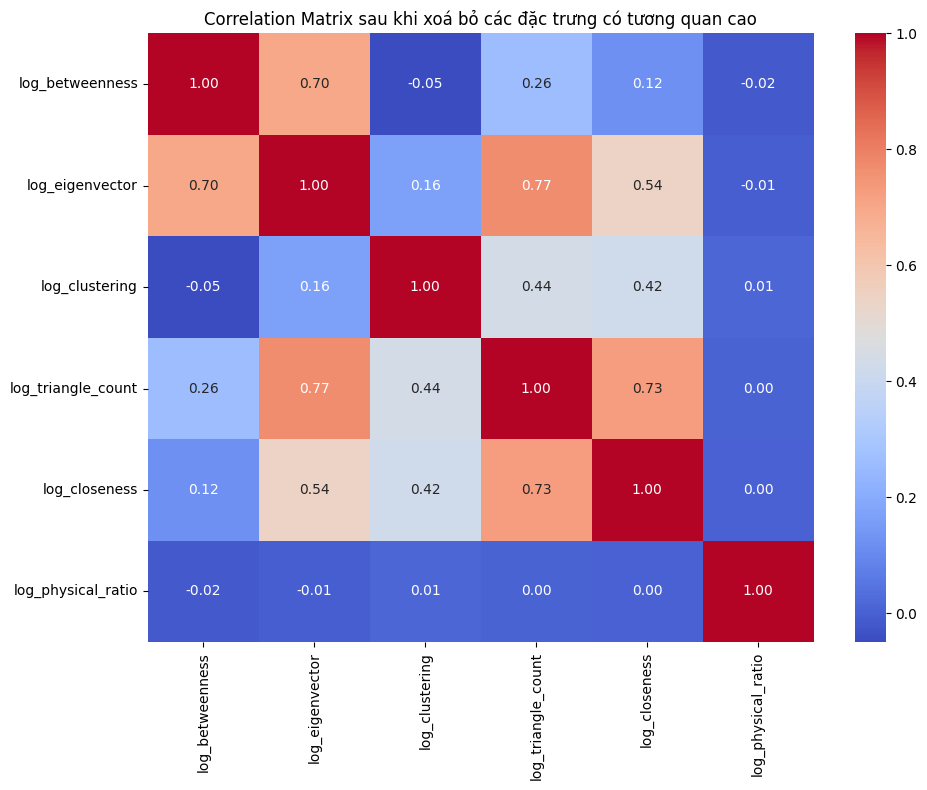

In [56]:
# Loại bỏ cột có độ tương quan trên 0.9
threshold = 0.9
drop_columns = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname = corr_matrix.columns[i]
            drop_columns.add(colname)

# Loại bỏ các cột đã chọn
df_reduced = log_features_df.drop(columns=drop_columns)

# Vẽ lại ma trận tương quan sau khi loại bỏ
reduced_corr_matrix = df_reduced.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(reduced_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix sau khi xoá bỏ các đặc trưng có tương quan cao")
plt.tight_layout()
plt.show()

In [57]:
# In các cột đã loại bỏ
print("Các cột loại bỏ:", drop_columns)

Các cột loại bỏ: {'log_degree_centrality', 'log_genetic_ratio', 'log_pagerank'}


In [58]:
remaining_columns = df_reduced.columns.tolist()
print("Các cột còn lại:", remaining_columns)

Các cột còn lại: ['log_betweenness', 'log_eigenvector', 'log_clustering', 'log_triangle_count', 'log_closeness', 'log_physical_ratio']


# Ghép và chuẩn hóa đặc trưng

In [59]:
x_nx = df_reduced

In [60]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_nx.values)  # sửa chỗ .numpy()
x_nx = torch.tensor(x_scaled, dtype=torch.float).to(device)

# Mapping node -> index
node_list = sorted(list(G.nodes()))
node_idx_mapping = {node: idx for idx, node in enumerate(node_list)}
edge_list = [(node_idx_mapping[u], node_idx_mapping[v]) for u, v in G.edges()]
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous().to(device)

# Trực quan hoá 1 node với tất cả đặc trưng của nó

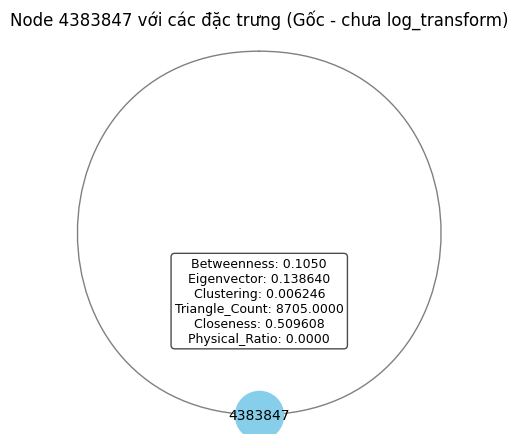

In [61]:
node_id = 4383847

if node_id in G.nodes:
    plt.figure(figsize=(4, 4))

    # Tạo subgraph chỉ chứa node cần vẽ
    subgraph = G.subgraph([node_id])
    pos = nx.spring_layout(subgraph, seed=42)

    # Vẽ node và nhãn
    nx.draw(
        subgraph,
        pos,
        with_labels=True,
        node_size=1200,
        node_color="skyblue",
        font_size=10,
        edge_color="gray"
    )

    # Lấy thông tin protein (ở đây bạn có thể lấy thông tin như bạn đã làm)
    protein_name = node_info.get(node_id, "Unknown")

    # Lấy giá trị của các đặc trưng gốc cho node này
    betweenness_value = betweenness.get(node_id, 0)
    eigenvector_value = eigenvector.get(node_id, 0)
    clustering_value = clustering.get(node_id, 0)
    triangle_count_value = triangle_count.get(node_id, 0)
    closeness_value = closeness.get(node_id, 0)

    # Nếu physical_vals là một list, lấy giá trị bằng cách tìm index của node_id
    try:
        physical_value = physical_vals[node_id]  # Truy cập trực tiếp theo index của node_id
    except IndexError:
        physical_value = 0  # Nếu không tìm thấy, gán giá trị mặc định

    # Soạn nội dung hiển thị
    text = (
        f"Betweenness: {betweenness_value:.4f}\n"
        f"Eigenvector: {eigenvector_value:.6f}\n"
        f"Clustering: {clustering_value:.6f}\n"
        f"Triangle_Count: {triangle_count_value:.4f}\n"
        f"Closeness: {closeness_value:.6f}\n"
        f"Physical_Ratio: {physical_value:.4f}"
    )

    # Hiển thị text phía trên node
    offset = 0.12
    plt.text(
        pos[node_id][0],
        pos[node_id][1] + offset,
        text,
        fontsize=9,
        ha='center',
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3")
    )

    plt.title(f"Node {node_id} với các đặc trưng (Gốc - chưa log_transform)")
    plt.axis("off")
    plt.show()
else:
    print(f"Node {node_id} không tồn tại trong đồ thị.")

# Tạo danh sách các edges và chia thành tập huấn luyện và kiểm tra

In [62]:
# Tạo PyG Data object và chia train/test
data = Data(x=x_nx, edge_index=edge_index)
# Xáo trộn cạnh để tránh bias khi chia train/test
edge_list = data.edge_index.t().tolist()
random.shuffle(edge_list)
data.edge_index = torch.tensor(edge_list, dtype=torch.long).t()
data = train_test_split_edges(data, val_ratio=0.15, test_ratio=0.15)

# Lấy edge cho training và testing
data.edge_index = data.train_pos_edge_index

# Tách ra các edge
edge_index_train = data.train_pos_edge_index
edge_index_val = data.val_pos_edge_index
edge_index_test = data.test_pos_edge_index

/usr/local/lib/python3.11/dist-packages/torch_geometric/deprecation.py:26: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  warnings.warn(out)


In [63]:
# Chuẩn hóa cạnh
def normalize_edge(u, v):
    return tuple(sorted((u, v)))

# Lấy các tập cạnh
train_edges = set(normalize_edge(u, v) for u, v in data.train_pos_edge_index.t().cpu().numpy())
val_edges = set(normalize_edge(u, v) for u, v in data.val_pos_edge_index.t().cpu().numpy())
test_edges = set(normalize_edge(u, v) for u, v in data.test_pos_edge_index.t().cpu().numpy())

# Thống kê số lượng và trùng lặp
print(f"Số cạnh trong train set: {len(train_edges)}")
print(f"Số cạnh trong val set:   {len(val_edges)}")
print(f"Số cạnh trong test set:  {len(test_edges)}")

print(f"Số cạnh trùng giữa train và val:  {len(train_edges & val_edges)}")
print(f"Số cạnh trùng giữa train và test: {len(train_edges & test_edges)}")
print(f"Số cạnh trùng giữa val và test:   {len(val_edges & test_edges)}")

Số cạnh trong train set: 6957
Số cạnh trong val set:   1490
Số cạnh trong test set:  1490
Số cạnh trùng giữa train và val:  0
Số cạnh trùng giữa train và test: 0
Số cạnh trùng giữa val và test:   0


# Xây dựng mô hình GCN

In [64]:
class GCNEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 64, 64], dropout=0.3):
        super(GCNEncoder, self).__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        prev_dim = input_dim
        for dim in hidden_dims:
            self.convs.append(GCNConv(prev_dim, dim))
            self.bns.append(nn.BatchNorm1d(dim))
            prev_dim = dim
        self.dropout = dropout

    def forward(self, x, edge_index):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.leaky_relu(x, 0.2)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x

In [65]:
def hadamard(u, v):
    return u * v

In [66]:
class EdgeDecoder(nn.Module):
    def __init__(self, input_dim):
        super(EdgeDecoder, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, edge_features):
        return self.mlp(edge_features)

In [67]:
model = GCNEncoder(input_dim=x_nx.shape[1]).to(device)
decoder = EdgeDecoder(input_dim=64).to(device)  # đầu vào của decoder là kích thước vector hadamard (64)
data = data.to(device)
optimizer = optim.Adam(
    list(model.parameters()) + list(decoder.parameters()),
    lr=0.001, weight_decay=1e-4
)

In [68]:
# Hàm huấn luyện
def train(model, decoder, optimizer, data, device):
    model.train()
    decoder.train()
    optimizer.zero_grad()

    x = data.x.to(device)
    edge_index = data.train_pos_edge_index.to(device).long()

    # Encode node features
    emb = model(x, edge_index)
    emb = F.normalize(emb, p=2, dim=1)

    # Positive edges
    src_pos, dst_pos = edge_index
    pos_edge_feat = hadamard(emb[src_pos], emb[dst_pos])
    pos_preds = decoder(pos_edge_feat).squeeze()

    # Negative edges
    neg_edge_index = negative_sampling(
        edge_index=edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=src_pos.size(0),
        force_undirected=True
    ).to(device)

    neg_src, neg_dst = neg_edge_index
    neg_edge_feat = hadamard(emb[neg_src], emb[neg_dst])
    neg_preds = decoder(neg_edge_feat).squeeze()

    # Combine
    preds = torch.cat([pos_preds, neg_preds])
    labels = torch.cat([torch.ones_like(pos_preds), torch.zeros_like(neg_preds)])

    loss = F.binary_cross_entropy(preds, labels)

    preds_prob = preds.detach().cpu().numpy()
    labels_true = labels.detach().cpu().numpy()
    train_auc = roc_auc_score(labels_true, preds_prob)

    loss.backward()
    optimizer.step()

    # Validation
    val_loss, val_auc, _, _, _, _ = evaluate(model, decoder, data, data.val_pos_edge_index, device)

    return loss.item(), train_auc, val_loss, val_auc


def plot_confusion_matrix(cm):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [69]:
def evaluate(model, decoder, data, edge_index_eval, device):
    model.eval()
    decoder.eval()
    with torch.no_grad():
        x = data.x.to(device)
        edge_index = data.train_pos_edge_index.to(device).long()
        emb = model(x, edge_index)
        emb = F.normalize(emb, p=2, dim=1)

        # Positive edges
        src_pos, dst_pos = edge_index_eval
        pos_edge_feat = hadamard(emb[src_pos], emb[dst_pos])
        pos_preds = decoder(pos_edge_feat).squeeze()

        # Negative edges

        neg_edge_index = negative_sampling(
            edge_index=edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=len(src_pos),
            force_undirected=True
        ).to(device)

        neg_src, neg_dst = neg_edge_index
        neg_edge_feat = hadamard(emb[neg_src], emb[neg_dst])
        neg_preds = decoder(neg_edge_feat).squeeze()

        preds = torch.cat([pos_preds, neg_preds]).cpu().numpy()
        labels = torch.cat([torch.ones_like(pos_preds), torch.zeros_like(neg_preds)]).cpu().numpy()

        preds_binary = (preds > 0.5).astype(int)

        test_loss = F.binary_cross_entropy(
            torch.cat([pos_preds, neg_preds]),
            torch.cat([torch.ones_like(pos_preds), torch.zeros_like(neg_preds)])
        ).item()
        test_auc = roc_auc_score(labels, preds)
        precision = precision_score(labels, preds_binary)
        recall = recall_score(labels, preds_binary)
        f1 = f1_score(labels, preds_binary)
        cm = confusion_matrix(labels, preds_binary)

        return test_loss, test_auc, precision, recall, f1, cm

In [70]:
def train_with_val(model, decoder, optimizer, data, device, val_edge_index):
    model.train()
    decoder.train()
    optimizer.zero_grad()

    # Huấn luyện trên tập train
    x = data.x.to(device)
    edge_index = data.train_pos_edge_index.to(device).long()

    emb = model(x, edge_index)
    emb = F.normalize(emb, p=2, dim=1)

    # Positive edges
    src_pos, dst_pos = edge_index
    pos_edge_feat = hadamard(emb[src_pos], emb[dst_pos])
    pos_preds = decoder(pos_edge_feat).squeeze()

    # Negative edges
    neg_edge_index = negative_sampling(
        edge_index=edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=src_pos.size(0),
        force_undirected=True
    ).to(device)

    neg_src, neg_dst = neg_edge_index
    neg_edge_feat = hadamard(emb[neg_src], emb[neg_dst])
    neg_preds = decoder(neg_edge_feat).squeeze()

    # Combine
    preds = torch.cat([pos_preds, neg_preds])
    labels = torch.cat([torch.ones_like(pos_preds), torch.zeros_like(neg_preds)])

    loss = F.binary_cross_entropy(preds, labels)

    preds_prob = preds.detach().cpu().numpy()
    labels_true = labels.detach().cpu().numpy()
    train_auc = roc_auc_score(labels_true, preds_prob)

    loss.backward()
    optimizer.step()

    # Đánh giá trên tập validation
    val_loss, val_auc, _, _, _, _ = evaluate(model, decoder, data, val_edge_index, device)

    return loss.item(), train_auc, val_loss, val_auc

In [71]:
num_epochs = 50
train_losses = []
val_losses = []
train_aucs = []
val_aucs = []

for epoch in range(num_epochs):
    train_loss, train_auc, val_loss, val_auc = train_with_val(model, decoder, optimizer, data, device, data.val_pos_edge_index)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_aucs.append(train_auc)
    val_aucs.append(val_auc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f}, AUC: {train_auc:.4f} | Val Loss: {val_loss:.4f}, AUC: {val_auc:.4f}")

Epoch 1/50 | Train Loss: 0.6986, AUC: 0.5004 | Val Loss: 0.6982, AUC: 0.3454
Epoch 2/50 | Train Loss: 0.6981, AUC: 0.5051 | Val Loss: 0.6977, AUC: 0.4827
Epoch 3/50 | Train Loss: 0.6976, AUC: 0.5123 | Val Loss: 0.6973, AUC: 0.5530
Epoch 4/50 | Train Loss: 0.6972, AUC: 0.5176 | Val Loss: 0.6968, AUC: 0.6761
Epoch 5/50 | Train Loss: 0.6968, AUC: 0.5205 | Val Loss: 0.6964, AUC: 0.7461
Epoch 6/50 | Train Loss: 0.6963, AUC: 0.5307 | Val Loss: 0.6960, AUC: 0.7959
Epoch 7/50 | Train Loss: 0.6959, AUC: 0.5386 | Val Loss: 0.6956, AUC: 0.8381
Epoch 8/50 | Train Loss: 0.6956, AUC: 0.5427 | Val Loss: 0.6952, AUC: 0.8567
Epoch 9/50 | Train Loss: 0.6951, AUC: 0.5557 | Val Loss: 0.6947, AUC: 0.8833
Epoch 10/50 | Train Loss: 0.6948, AUC: 0.5625 | Val Loss: 0.6943, AUC: 0.8885
Epoch 11/50 | Train Loss: 0.6943, AUC: 0.5776 | Val Loss: 0.6937, AUC: 0.9047
Epoch 12/50 | Train Loss: 0.6938, AUC: 0.5883 | Val Loss: 0.6934, AUC: 0.8847
Epoch 13/50 | Train Loss: 0.6937, AUC: 0.5847 | Val Loss: 0.6929, AUC: 0.

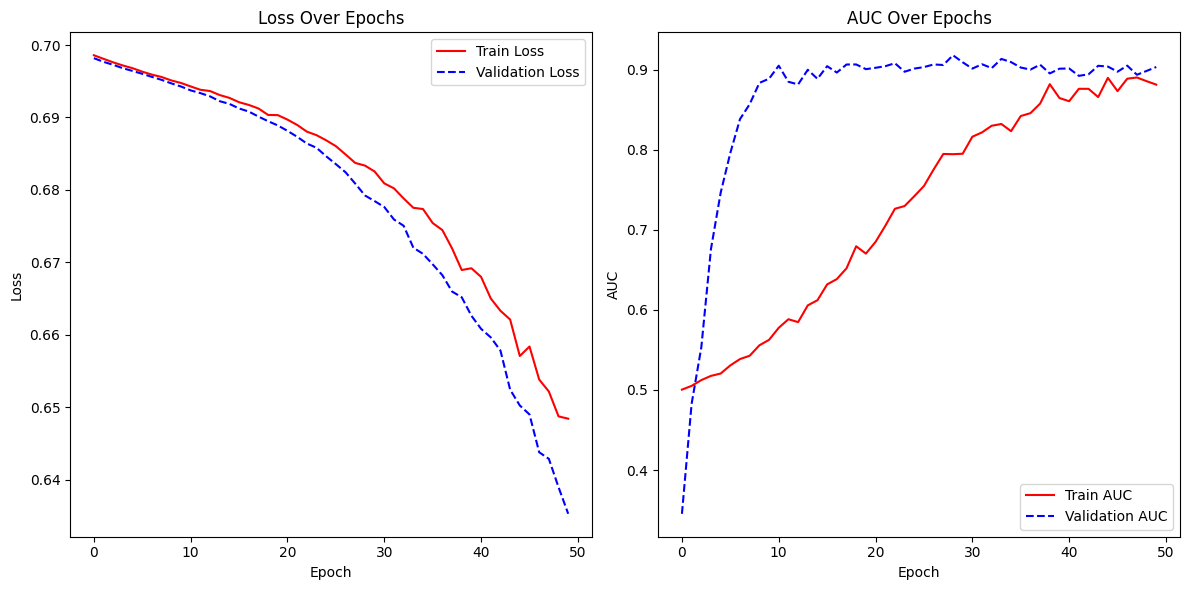

In [72]:
# Trực quan hóa loss và AUC
plt.figure(figsize=(12, 6))

# Vẽ loss
plt.subplot(1, 2, 1)
plt.plot(range(len(train_losses)), train_losses, label='Train Loss', color='red')
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss', color='blue', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()

# Vẽ AUC
plt.subplot(1, 2, 2)
plt.plot(range(len(train_aucs)), train_aucs, label='Train AUC', color='red')
plt.plot(range(len(val_aucs)), val_aucs, label='Validation AUC', color='blue', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('AUC Over Epochs')
plt.legend()

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()


===== Final Evaluation =====
Train Loss: 0.6484
Train AUC: 0.8811
Test Loss: 0.6356
Test AUC: 0.8972
Test Precision: 0.7795
Test Recall: 0.8255
Test F1-score: 0.8018


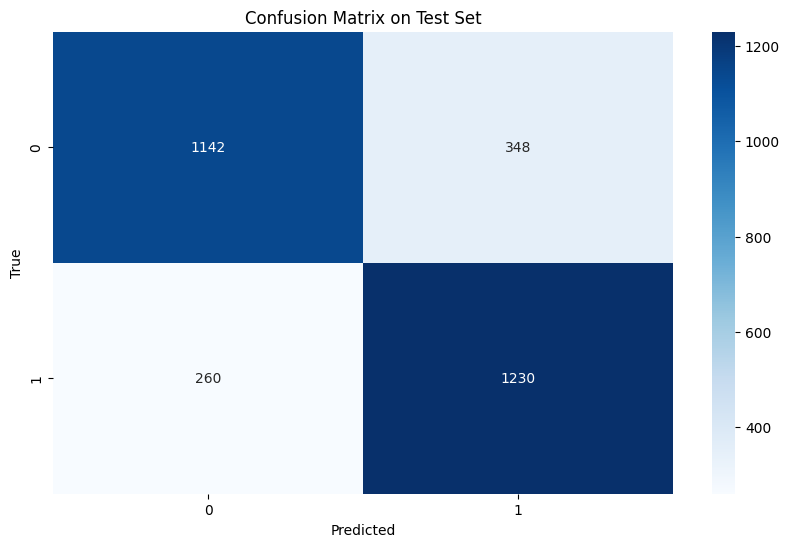

In [73]:
test_loss, test_auc, precision, recall, f1, cm = evaluate(model, decoder, data, data.test_pos_edge_index, device)

print("\n===== Final Evaluation =====")
print(f"Train Loss: {train_losses[-1]:.4f}")
print(f"Train AUC: {train_aucs[-1]:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-score: {f1:.4f}")

# Vẽ Confusion Matrix
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

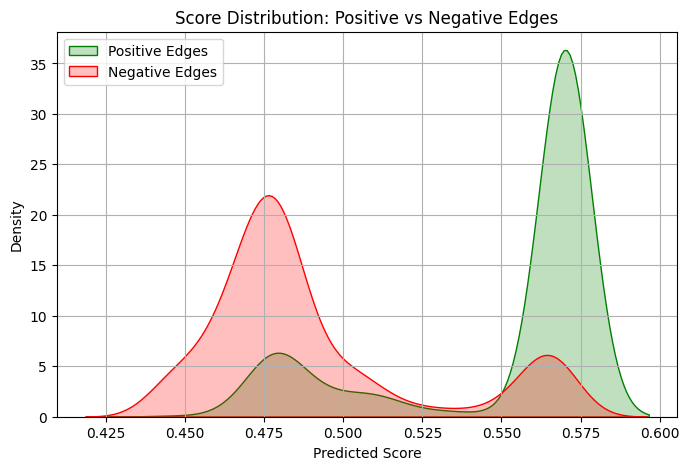

In [74]:
def plot_score_distribution(model, decoder, data, edge_index_eval, device):
    model.eval()
    decoder.eval()

    with torch.no_grad():
        x = data.x.to(device)
        edge_index = data.train_pos_edge_index.to(device).long()

        # Lấy embedding
        emb = model(x, edge_index)
        emb = F.normalize(emb, p=2, dim=1)

        # Positive edges
        src_pos, dst_pos = edge_index_eval
        pos_feat = hadamard(emb[src_pos], emb[dst_pos])
        pos_scores = decoder(pos_feat).squeeze().cpu().numpy()

        # Negative edges (sampling bằng số lượng cạnh dương)

        neg_edge_index = negative_sampling(
            edge_index=edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=len(src_pos),
            force_undirected=True
        ).to(device)

        neg_src, neg_dst = neg_edge_index
        neg_feat = hadamard(emb[neg_src], emb[neg_dst])
        neg_scores = decoder(neg_feat).squeeze().cpu().numpy()

    # Plot
    plt.figure(figsize=(8,5))
    sns.kdeplot(pos_scores, label='Positive Edges', fill=True, color='green')
    sns.kdeplot(neg_scores, label='Negative Edges', fill=True, color='red')
    plt.xlabel("Predicted Score")
    plt.ylabel("Density")
    plt.title("Score Distribution: Positive vs Negative Edges")
    plt.legend()
    plt.grid(True)
    plt.show()

# Gọi hàm
plot_score_distribution(model, decoder, data, data.test_pos_edge_index, device)

# Dự đoán liên kết

In [75]:
def get_unconnected_pairs(G, num_samples=10):
    # Lấy danh sách các cặp node chưa kết nối
    unconnected = list(nx.non_edges(G))
    # Lấy ngẫu nhiên num_samples cặp
    return random.sample(unconnected, min(num_samples, len(unconnected)))

In [76]:
def predict_unseen_links(pairs, model, decoder, data, node_idx_mapping, node_info):
    model.eval()
    decoder.eval()
    with torch.no_grad():
        x = data.x.to(device)
        edge_index = data.train_pos_edge_index.to(device).long()
        emb = model(x, edge_index)
        emb = F.normalize(emb, p=2, dim=1)

        results = []
        for u, v in pairs:
            idx_u, idx_v = node_idx_mapping[u], node_idx_mapping[v]
            feat = hadamard(emb[idx_u], emb[idx_v])
            score = decoder(feat.unsqueeze(0)).item()  # Đưa vào decoder để tính điểm
            results.append({
                "Protein A ID": u,
                "Protein A": node_info[u],
                "Protein B ID": v,
                "Protein B": node_info[v],
                "Score": score
            })

        # Sắp xếp theo điểm dự đoán giảm dần
        results.sort(key=lambda x: x["Score"], reverse=True)
        return results

In [77]:
# Lấy 10 cặp node chưa kết nối
unseen_pairs = get_unconnected_pairs(G, num_samples=10)

# Dự đoán điểm liên kết
predictions = predict_unseen_links(unseen_pairs, model, decoder, data, node_idx_mapping, node_info)

# In ra bảng kết quả
import pandas as pd
df_pre = pd.DataFrame(predictions)
print(df_pre.to_string(index=False))

 Protein A ID Protein A  Protein B ID Protein B    Score
       107432     CDC34        108360     EPHA8 0.487804
       121271       MFF        123894     PRAM1 0.486641
       137505  C9orf173        112286      SDC4 0.482402
       108811      FZD2        110050      KRT5 0.480510
       107720    COX4I1        107790     CRMP1 0.473541
       109708    IGFBP4        118942      GNL2 0.461644
       117101    SNAPIN        124975    BPIFB1 0.460870
       107683    COL4A4        124370   ZFYVE19 0.457185
       131495     PDDC1        106842     APOC3 0.445987
       137505  C9orf173        109708    IGFBP4 0.443155
